In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import lognorm
from scipy.stats import kurtosis
from scipy.stats import norm


## Simulating Returns Normally

In [3]:
N = 5 * 60
S0 = 100


mu = 0
sigma = 0.01

log_returns = pd.Series(
    np.random.normal(mu, sigma, size=N),
    name="log_ret"
)

prices = S0 * np.exp(log_returns.cumsum())



In [5]:
def simulate_log_returns(mu, sigma, N, S0=100, return_full=False):
    log_returns = pd.Series(
        np.random.normal(mu, sigma, size=N),
        name="log_ret"
    )

    
    prices = S0 * np.exp(log_returns.cumsum())

    if return_full:
        return prices

    return prices.iloc[-1]

In [10]:
n_sims = 100000

final_prices = []

for _ in range(n_sims):
    final_price = simulate_log_returns(mu, sigma, N)

    final_prices.append(final_price)

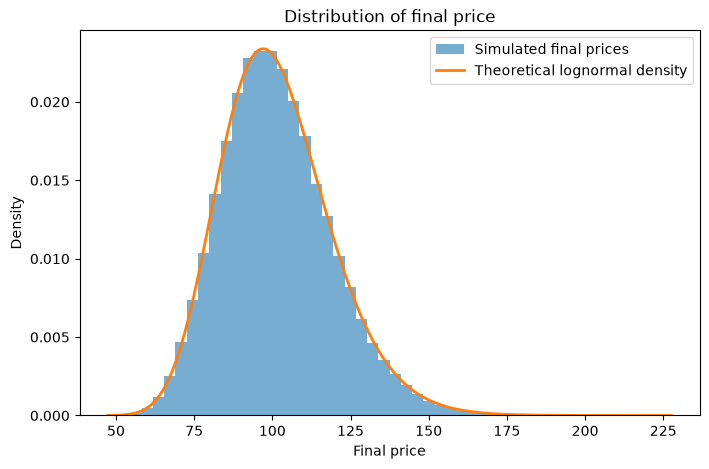

In [15]:
final_prices = np.array(final_prices)

log_mean = np.log(S0) + N * mu
log_std = np.sqrt(N) * sigma

# x-grid for theoretical density
x = np.linspace(final_prices.min(), final_prices.max(), 1000)
pdf = lognorm.pdf(x, s=log_std, scale=np.exp(log_mean))

# plot
plt.figure(figsize=(8, 5))
plt.hist(final_prices, bins=50, density=True, alpha=0.6, label="Simulated final prices")
plt.plot(x, pdf, linewidth=2, label="Theoretical lognormal density")
plt.xlabel("Final price")
plt.ylabel("Density")
plt.title("Distribution of final price")
plt.legend()
plt.show()

### What happens if we use the TWAP

In [16]:
n_sims = 100000

twap_prices = []

for _ in range(n_sims):
    twap_price = simulate_log_returns(mu, sigma, N, return_full=True)[-60:].mean()

    twap_prices.append(twap_price)

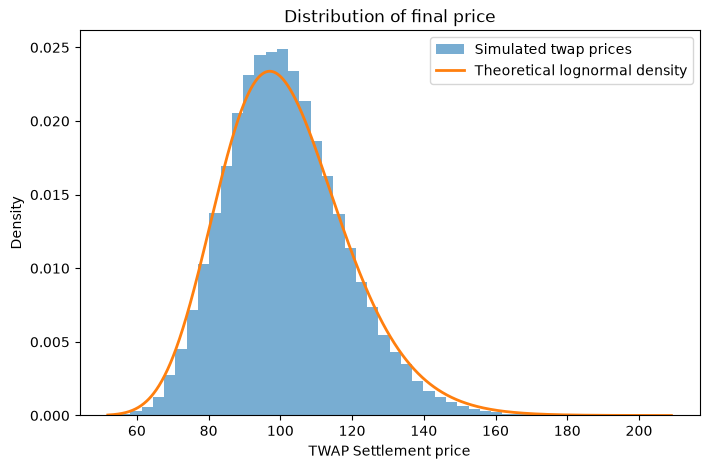

In [35]:
twap_prices = np.array(twap_prices)

log_mean = np.log(S0) + N * mu
log_std = np.sqrt(N) * sigma

# x-grid for theoretical density
x = np.linspace(twap_prices.min(), twap_prices.max(), 1000)
pdf = lognorm.pdf(x, s=log_std, scale=np.exp(log_mean))

# plot
plt.figure(figsize=(8, 5))
plt.hist(twap_prices, bins=50, density=True, alpha=0.6, label="Simulated twap prices")
plt.plot(x, pdf, linewidth=2, label="Theoretical lognormal density")
plt.xlabel("TWAP Settlement price")
plt.ylabel("Density")
plt.title("Distribution of final price")
plt.legend()
plt.show()

In [36]:
N_twap = 270

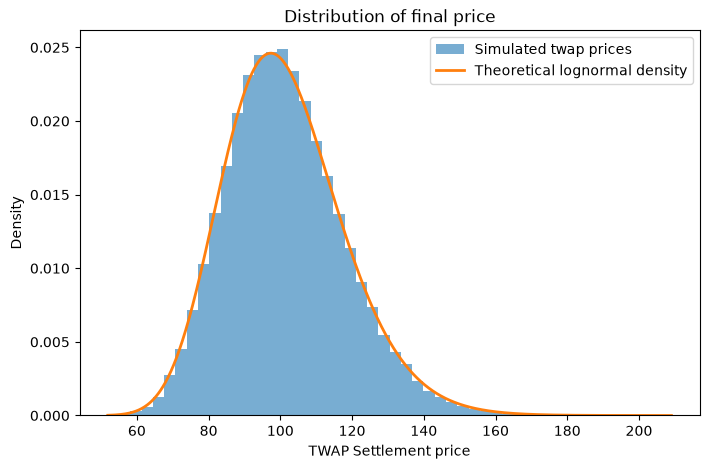

In [37]:

log_mean = np.log(S0) + N_twap * mu
log_std = np.sqrt(N_twap) * sigma

# x-grid for theoretical density
x = np.linspace(twap_prices.min(), twap_prices.max(), 1000)
pdf = lognorm.pdf(x, s=log_std, scale=np.exp(log_mean))

# plot
plt.figure(figsize=(8, 5))
plt.hist(twap_prices, bins=50, density=True, alpha=0.6, label="Simulated twap prices")
plt.plot(x, pdf, linewidth=2, label="Theoretical lognormal density")
plt.xlabel("TWAP Settlement price")
plt.ylabel("Density")
plt.title("Distribution of final price")
plt.legend()
plt.show()

In [38]:
counts, bin_edges = np.histogram(twap_prices, bins=100)
p = counts / counts.sum()

# Ignore empty empirical bins in KL
mask = p > 0


def kl_divergence(N_twap):
    log_mean = np.log(S0) + N_twap * mu
    log_std = np.sqrt(N_twap) * sigma

    # Theoretical probability in each histogram bin
    cdf = lognorm.cdf(
        bin_edges,
        s=log_std,
        scale=np.exp(log_mean)
    )

    q = np.diff(cdf)

    # Prevent log(0)
    q = np.maximum(q, 1e-15)

    return np.sum(
        p[mask] * np.log(p[mask] / q[mask])
    )


# Search possible N_twap values
N_values = np.arange(1, N + 1)

kl_values = np.array([
    kl_divergence(N_twap)
    for N_twap in N_values
])

best_N_twap = N_values[np.argmin(kl_values)]

print("Best N_twap:", best_N_twap)
print("Minimum KL:", kl_values.min())

Best N_twap: 260
Minimum KL: 0.0005518664192900672


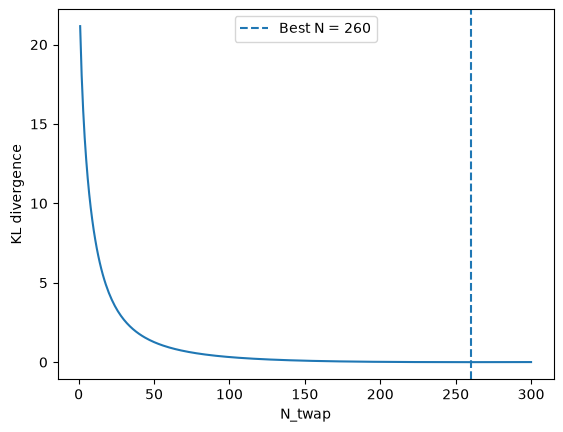

In [39]:
plt.plot(N_values, kl_values)
plt.axvline(best_N_twap, linestyle="--", label=f"Best N = {best_N_twap}")

plt.xlabel("N_twap")
plt.ylabel("KL divergence")
plt.legend()
plt.show()

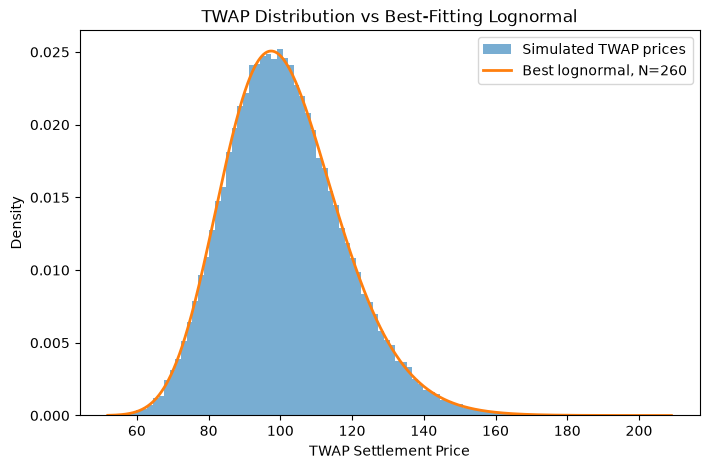

In [40]:
log_mean = np.log(S0) + best_N_twap * mu
log_std = np.sqrt(best_N_twap) * sigma

x = np.linspace(twap_prices.min(), twap_prices.max(), 1000)

pdf = lognorm.pdf(
    x,
    s=log_std,
    scale=np.exp(log_mean)
)

plt.figure(figsize=(8, 5))

plt.hist(
    twap_prices,
    bins=100,
    density=True,
    alpha=0.6,
    label="Simulated TWAP prices"
)

plt.plot(
    x,
    pdf,
    linewidth=2,
    label=f"Best lognormal, N={best_N_twap}"
)

plt.xlabel("TWAP Settlement Price")
plt.ylabel("Density")
plt.title("TWAP Distribution vs Best-Fitting Lognormal")
plt.legend()
plt.show()

## Trying with the actual vol numbers

In [64]:
n_sims = 100000
N = 300
annual_vol = 0.16
per_second_vol = annual_vol / np.sqrt(365 * 24 * 60 * 60)
mu = 0

twap_prices = []

for _ in range(n_sims):
    twap_price = simulate_log_returns(
        mu,
        per_second_vol,
        N,
        return_full=True
    )[-60:].mean()

    twap_prices.append(twap_price)

twap_prices = np.array(twap_prices)

In [65]:
twap_prices = np.array(twap_prices)

### Normal Approximation

In [74]:
m = 60

N_eff = (
    N - m
    + (m + 1) * (2*m + 1) / (6*m)
)

analytic_mean = S0
analytic_std = S0 * per_second_vol * np.sqrt(N_eff)

print("N_eff:", N_eff)
print("Analytic mean:", analytic_mean)
print("Analytic std:", analytic_std)

N_eff: 260.5027777777778
Analytic mean: 100
Analytic std: 0.045985706007396515


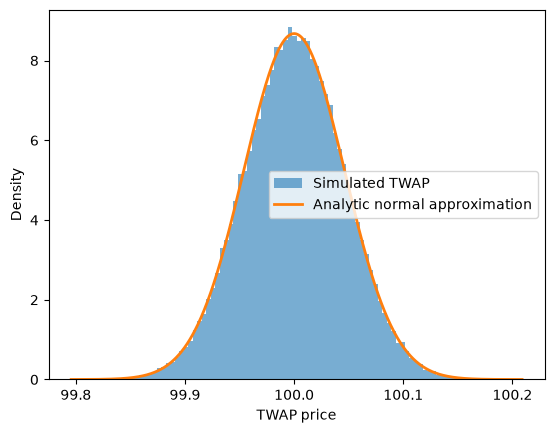

In [75]:
x = np.linspace(twap_prices.min(), twap_prices.max(), 1000)

pdf = norm.pdf(
    x,
    loc=analytic_mean,
    scale=analytic_std
)

plt.hist(
    twap_prices,
    bins=100,
    density=True,
    alpha=0.6,
    label="Simulated TWAP"
)

plt.plot(
    x,
    pdf,
    linewidth=2,
    label="Analytic normal approximation"
)

plt.xlabel("TWAP price")
plt.ylabel("Density")
plt.legend()
plt.show()

## During the TWAP

In [76]:
def twap_prob_up_live(
    K,
    current_price,
    mean_so_far,
    n_observed,
    m,
    mu,
    sigma,
):
    """
    Analytic approximation to P(final TWAP > K)
    after the TWAP window has already started.

    Parameters
    ----------
    K : float
        Settlement threshold / strike.

    current_price : float
        Current price (most recently observed TWAP price).

    mean_so_far : float
        Mean of TWAP observations already collected.

    n_observed : int
        Number of TWAP observations already collected.

    m : int
        Total number of observations in the TWAP.

    mu : float
        Per-step log-return mean.

    sigma : float
        Per-step log-return standard deviation.
    """

    known_sum = mean_so_far * n_observed
    n_remaining = m - n_observed

    # TWAP is already finished
    if n_remaining == 0:
        final_twap = known_sum / m
        return float(final_twap > K)

    # Future times relative to now: 1, ..., n_remaining
    times = np.arange(1, n_remaining + 1)

    # Exact conditional means of future prices
    E_S = current_price * np.exp(
        times * mu + 0.5 * times * sigma**2
    )

    future_mean_sum = E_S.sum()

    # Exact conditional second moments E[S_i S_j]
    i = times[:, None]
    j = times[None, :]

    E_SiSj = current_price**2 * np.exp(
        (i + j) * mu
        + 0.5 * sigma**2
        * (i + j + 2 * np.minimum(i, j))
    )

    # Covariance matrix
    cov = E_SiSj - E_S[:, None] * E_S[None, :]

    future_var_sum = cov.sum()

    # Final TWAP mean and variance
    twap_mean = (known_sum + future_mean_sum) / m
    twap_var = future_var_sum / m**2
    twap_std = np.sqrt(twap_var)

    # Normal approximation
    p_up = norm.sf(
        K,
        loc=twap_mean,
        scale=twap_std
    )

    return p_up

In [77]:
p_up = twap_prob_up_live(
    K=100,
    current_price=100.03,
    mean_so_far=99.98,
    n_observed=20,
    m=60,
    mu=0,
    sigma=per_second_vol,
)

print(p_up)

0.9703907239804174


## Some Comparisons

LIVE STATE
----------
Observed TWAP prices : 30
Remaining prices     : 30
Current price        : 100.088214
TWAP mean so far     : 100.086434

         mark  sim_before  approx_before  error_before  sim_live  approx_live  \
0    99.88504     0.99381        0.99379      -0.00002   1.00000      1.00000   
1    99.89653     0.98785        0.98778      -0.00007   1.00000      1.00000   
2    99.90803     0.97712        0.97726       0.00014   1.00000      1.00000   
3    99.91953     0.96026        0.95996      -0.00030   1.00000      1.00000   
4    99.93102     0.93374        0.93322      -0.00052   1.00000      1.00000   
5    99.94252     0.89454        0.89439      -0.00015   1.00000      1.00000   
6    99.95401     0.84128        0.84140       0.00012   1.00000      1.00000   
7    99.96551     0.77307        0.77344       0.00037   1.00000      1.00000   
8    99.97701     0.69236        0.69155      -0.00081   1.00000      1.00000   
9    99.98850     0.59888        0.59880      -

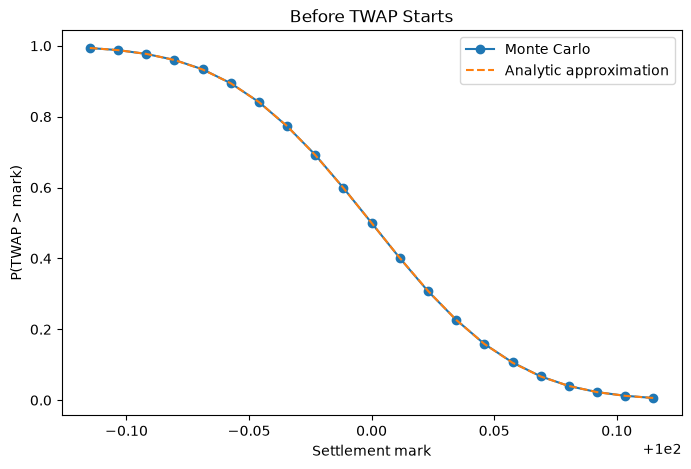

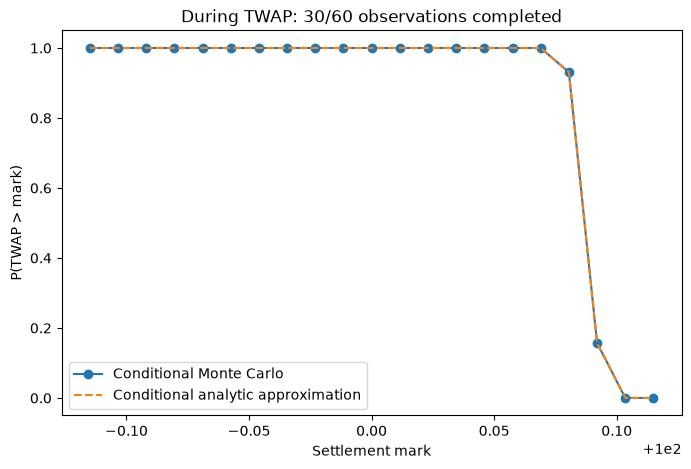

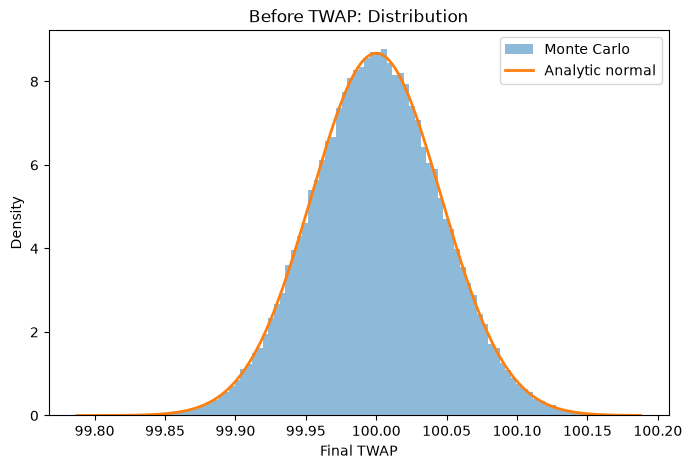

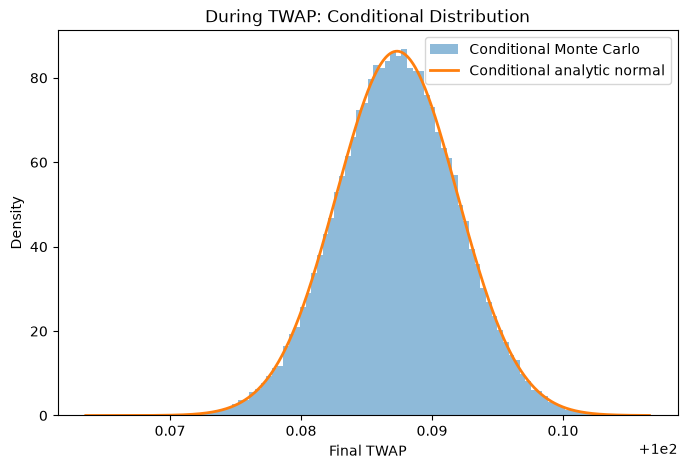

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm


# ============================================================
# PARAMETERS
# ============================================================

S0 = 100.0

annual_vol = 0.16
sigma = annual_vol / np.sqrt(365 * 24 * 60 * 60)
mu = 0.0

N = 300          # steps from now until end of TWAP
m = 60           # number of prices in TWAP
k = 30           # number of TWAP observations already observed in "live" case

n_sims = 100_000

rng = np.random.default_rng(42)


# ============================================================
# SIMULATION HELPERS
# ============================================================

def simulate_prices(S0, mu, sigma, n_steps, n_sims, rng):
    """
    Simulate n_sims price paths, each with n_steps future prices.

    Shape returned:
        (n_sims, n_steps)
    """
    log_returns = rng.normal(
        mu,
        sigma,
        size=(n_sims, n_steps)
    )

    log_prices = np.cumsum(log_returns, axis=1)

    return S0 * np.exp(log_prices)


# ============================================================
# EXACT MOMENTS OF AN ARITHMETIC TWAP
# ============================================================

def twap_moments_before(S0, mu, sigma, N, m):
    """
    Exact first two moments of a TWAP over the final m prices
    of an N-step GBM/lognormal path.
    """

    times = np.arange(N - m + 1, N + 1)

    # E[S_t]
    E_S = S0 * np.exp(
        times * mu
        + 0.5 * times * sigma**2
    )

    twap_mean = E_S.mean()

    # E[S_i S_j]
    i = times[:, None]
    j = times[None, :]

    E_SS = S0**2 * np.exp(
        (i + j) * mu
        + 0.5 * sigma**2 *
        (i + j + 2 * np.minimum(i, j))
    )

    twap_second_moment = E_SS.mean()

    twap_var = (
        twap_second_moment
        - twap_mean**2
    )

    return twap_mean, twap_var


# ============================================================
# CONDITIONAL MOMENTS ONCE TWAP HAS STARTED
# ============================================================

def twap_moments_live(
    current_price,
    mean_so_far,
    n_observed,
    m,
    mu,
    sigma
):
    """
    Conditional first two moments of final TWAP given:

        current_price
        mean_so_far
        n_observed

    Assumes remaining prices evolve from current_price.
    """

    n_remaining = m - n_observed
    known_sum = n_observed * mean_so_far

    if n_remaining == 0:
        return known_sum / m, 0.0

    times = np.arange(1, n_remaining + 1)

    # Conditional future price means
    E_S = current_price * np.exp(
        times * mu
        + 0.5 * times * sigma**2
    )

    # Conditional E[S_i S_j]
    i = times[:, None]
    j = times[None, :]

    E_SS = current_price**2 * np.exp(
        (i + j) * mu
        + 0.5 * sigma**2 *
        (i + j + 2 * np.minimum(i, j))
    )

    cov = (
        E_SS
        - E_S[:, None] * E_S[None, :]
    )

    twap_mean = (
        known_sum + E_S.sum()
    ) / m

    twap_var = cov.sum() / m**2

    return twap_mean, twap_var


# ============================================================
# 1. BEFORE TWAP STARTS
# ============================================================

paths = simulate_prices(
    S0=S0,
    mu=mu,
    sigma=sigma,
    n_steps=N,
    n_sims=n_sims,
    rng=rng
)

twap_sims_before = paths[:, -m:].mean(axis=1)

mean_before, var_before = twap_moments_before(
    S0=S0,
    mu=mu,
    sigma=sigma,
    N=N,
    m=m
)

std_before = np.sqrt(var_before)


# ============================================================
# 2. CREATE ONE OBSERVED PARTIAL TWAP PATH
# ============================================================

# Simulate a price path up to the start of the TWAP
pre_twap_steps = N - m

pre_path = simulate_prices(
    S0=S0,
    mu=mu,
    sigma=sigma,
    n_steps=pre_twap_steps,
    n_sims=1,
    rng=rng
)[0]

price_at_twap_start = (
    S0 if pre_twap_steps == 0
    else pre_path[-1]
)

# Simulate the first k observations of this particular TWAP
observed_twap = simulate_prices(
    S0=price_at_twap_start,
    mu=mu,
    sigma=sigma,
    n_steps=k,
    n_sims=1,
    rng=rng
)[0]

current_price = observed_twap[-1]
mean_so_far = observed_twap.mean()

print("LIVE STATE")
print("----------")
print(f"Observed TWAP prices : {k}")
print(f"Remaining prices     : {m-k}")
print(f"Current price        : {current_price:.6f}")
print(f"TWAP mean so far     : {mean_so_far:.6f}")
print()


# ============================================================
# 3. CONDITIONAL MONTE CARLO FROM THAT EXACT STATE
# ============================================================

n_remaining = m - k

future_paths = simulate_prices(
    S0=current_price,
    mu=mu,
    sigma=sigma,
    n_steps=n_remaining,
    n_sims=n_sims,
    rng=rng
)

known_sum = observed_twap.sum()

twap_sims_live = (
    known_sum
    + future_paths.sum(axis=1)
) / m


mean_live, var_live = twap_moments_live(
    current_price=current_price,
    mean_so_far=mean_so_far,
    n_observed=k,
    m=m,
    mu=mu,
    sigma=sigma
)

std_live = np.sqrt(var_live)


# ============================================================
# MARKS TO TEST
# ============================================================

# Choose marks around the relevant distributions
common_std = max(std_before, std_live)

marks = np.linspace(
    S0 - 2.5 * common_std,
    S0 + 2.5 * common_std,
    21
)


# ============================================================
# COMPUTE PROBABILITIES
# ============================================================

rows = []

for mark in marks:

    # -----------------------
    # BEFORE TWAP
    # -----------------------

    p_sim_before = np.mean(
        twap_sims_before > mark
    )

    p_approx_before = norm.sf(
        mark,
        loc=mean_before,
        scale=std_before
    )

    # -----------------------
    # LIVE TWAP
    # -----------------------

    p_sim_live = np.mean(
        twap_sims_live > mark
    )

    if std_live > 0:
        p_approx_live = norm.sf(
            mark,
            loc=mean_live,
            scale=std_live
        )
    else:
        p_approx_live = float(
            mean_live > mark
        )

    rows.append({
        "mark": mark,

        "sim_before": p_sim_before,
        "approx_before": p_approx_before,
        "error_before": (
            p_approx_before - p_sim_before
        ),

        "sim_live": p_sim_live,
        "approx_live": p_approx_live,
        "error_live": (
            p_approx_live - p_sim_live
        ),
    })


results = pd.DataFrame(rows)

print(results.round(5))


# ============================================================
# SUMMARY ERRORS
# ============================================================

print()
print("BEFORE TWAP")
print("-----------")
print(
    "Max abs prob error:",
    np.abs(results["error_before"]).max()
)
print(
    "Mean abs prob error:",
    np.abs(results["error_before"]).mean()
)

print()
print("DURING TWAP")
print("-----------")
print(
    "Max abs prob error:",
    np.abs(results["error_live"]).max()
)
print(
    "Mean abs prob error:",
    np.abs(results["error_live"]).mean()
)


# ============================================================
# PLOT: BEFORE TWAP
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    results["mark"],
    results["sim_before"],
    marker="o",
    label="Monte Carlo"
)

plt.plot(
    results["mark"],
    results["approx_before"],
    linestyle="--",
    label="Analytic approximation"
)

plt.xlabel("Settlement mark")
plt.ylabel("P(TWAP > mark)")
plt.title("Before TWAP Starts")
plt.legend()
plt.show()


# ============================================================
# PLOT: DURING TWAP
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    results["mark"],
    results["sim_live"],
    marker="o",
    label="Conditional Monte Carlo"
)

plt.plot(
    results["mark"],
    results["approx_live"],
    linestyle="--",
    label="Conditional analytic approximation"
)

plt.xlabel("Settlement mark")
plt.ylabel("P(TWAP > mark)")
plt.title(
    f"During TWAP: {k}/{m} observations completed"
)
plt.legend()
plt.show()


# ============================================================
# OPTIONAL: DISTRIBUTION CHECKS
# ============================================================

x_before = np.linspace(
    twap_sims_before.min(),
    twap_sims_before.max(),
    1000
)

plt.figure(figsize=(8, 5))

plt.hist(
    twap_sims_before,
    bins=100,
    density=True,
    alpha=0.5,
    label="Monte Carlo"
)

plt.plot(
    x_before,
    norm.pdf(
        x_before,
        loc=mean_before,
        scale=std_before
    ),
    linewidth=2,
    label="Analytic normal"
)

plt.xlabel("Final TWAP")
plt.ylabel("Density")
plt.title("Before TWAP: Distribution")
plt.legend()
plt.show()


x_live = np.linspace(
    twap_sims_live.min(),
    twap_sims_live.max(),
    1000
)

plt.figure(figsize=(8, 5))

plt.hist(
    twap_sims_live,
    bins=100,
    density=True,
    alpha=0.5,
    label="Conditional Monte Carlo"
)

plt.plot(
    x_live,
    norm.pdf(
        x_live,
        loc=mean_live,
        scale=std_live
    ),
    linewidth=2,
    label="Conditional analytic normal"
)

plt.xlabel("Final TWAP")
plt.ylabel("Density")
plt.title("During TWAP: Conditional Distribution")
plt.legend()
plt.show()